### Sentiment Analysis


###  1. Problem Overview.
We are given a large dataset of customer product reviews collected by an e‑commerce platform.
The goal is to build an AI‑based sentiment classification system that predicts whether a review expresses:

- Positive
- Neutral
- Negative

sentiment based on the review text.

The solution implements a complete AI pipeline, including:

- data preprocessing,
- feature extraction,
- training multiple models,
- evaluation on a held‑out test set.

###  2. Import Required Libraries


In [46]:
# --- Core ---
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # display errors only

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 3. Load Training and Test Datasets (Parquet)
Two separate datasets are provided:

- a training set used exclusively for model fitting and validation,
- a test set used only for final evaluation.

In [27]:
train_df = pd.read_parquet("train-product-review.parquet")
test_df  = pd.read_parquet("test-product-review.parquet")

### 4. Exploratory Data Analysis (EDA)
Before modelling, we inspect class balance and language distribution.

In [47]:
train_df["stars"].value_counts().sort_index()

stars
1    4059
2    3960
3    4006
4    3968
5    4007
Name: count, dtype: int64

In [48]:
train_df["language"].value_counts()

language
en    6736
de    6634
fr    6630
Name: count, dtype: int64

### 5. Sentiment Mapping
Customer ratings are mapped to sentiment labels as follows:

- 1–2 stars → Negative
- 3 stars   → Neutral
- 4–5 stars → Positive

In [49]:
def map_sentiment(stars):
    if stars <= 2:
        return "Negative"
    elif stars == 3:
        return "Neutral"
    else:
        return "Positive"


train_df["sentiment"] = train_df["stars"].apply(map_sentiment)
test_df["sentiment"]  = test_df["stars"].apply(map_sentiment)


### 6. Text Cleaning and Normalisation
To ensure consistency across languages and reviews, we apply lightweight text cleaning:

- lowercasing,
- removing punctuation and URLs,
- whitespace normalisation.

In [50]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_review"] = train_df["review_body"].astype(str).apply(clean_text)
test_df["clean_review"]  = test_df["review_body"].astype(str).apply(clean_text)

In [32]:
X_train = train_df["clean_review"]
y_train = train_df["sentiment"]

X_test = test_df["clean_review"]
y_test = test_df["sentiment"]

In [33]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

In [34]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg.predict(X_test_tfidf)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.684
              precision    recall  f1-score   support

    Negative       0.71      0.81      0.76       596
     Neutral       0.38      0.17      0.24       292
    Positive       0.72      0.80      0.76       612

    accuracy                           0.68      1500
   macro avg       0.60      0.60      0.58      1500
weighted avg       0.65      0.68      0.66      1500



In [35]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=100,
    random_state=42
)

mlp.fit(X_train_tfidf, y_train)
y_pred_mlp = mlp.predict(X_test_tfidf)

print("MLP Accuracy:",
      accuracy_score(y_test, y_pred_mlp))

print(classification_report(y_test, y_pred_mlp))

MLP Accuracy: 0.6346666666666667
              precision    recall  f1-score   support

    Negative       0.73      0.67      0.70       596
     Neutral       0.34      0.40      0.37       292
    Positive       0.72      0.71      0.71       612

    accuracy                           0.63      1500
   macro avg       0.60      0.59      0.59      1500
weighted avg       0.65      0.63      0.64      1500



In [14]:
tfidf_uni = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 1),
    stop_words="english"
)

X_train_uni = tfidf_uni.fit_transform(X_train)
X_test_uni = tfidf_uni.transform(X_test)

In [36]:
log_reg_uni = LogisticRegression(max_iter=1000)
log_reg_uni.fit(X_train_uni, y_train)

y_pred_uni = log_reg_uni.predict(X_test_uni)

print("Unigram LR Accuracy:",
      accuracy_score(y_test, y_pred_uni))

Unigram LR Accuracy: 0.6773333333333333


In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 3]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=1
)

grid_lr.fit(X_train_tfidf, y_train)
best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_test_tfidf)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


In [38]:
print("Best parameters:", grid_lr.best_params_)
print("Best CV score:", grid_lr.best_score_)

Best parameters: {'C': 3}
Best CV score: 0.5875333836030802


In [39]:
best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_test_tfidf)

print("Tuned LR Accuracy:",
      accuracy_score(y_test, y_pred_best_lr))

print(classification_report(y_test, y_pred_best_lr))

Tuned LR Accuracy: 0.6833333333333333
              precision    recall  f1-score   support

    Negative       0.72      0.78      0.75       596
     Neutral       0.40      0.27      0.33       292
    Positive       0.73      0.78      0.75       612

    accuracy                           0.68      1500
   macro avg       0.62      0.61      0.61      1500
weighted avg       0.66      0.68      0.67      1500



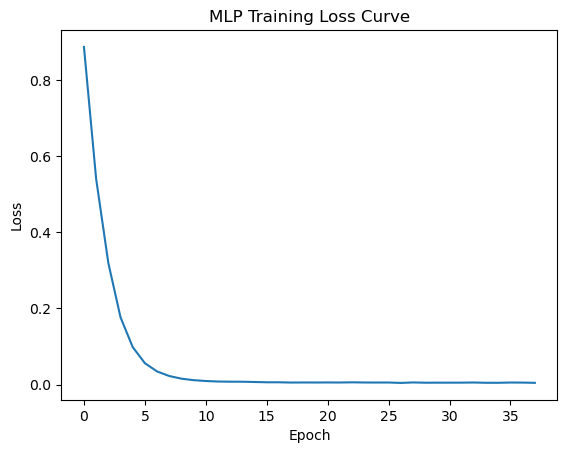

In [40]:
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [41]:

errors = X_test[y_test != y_pred_best_lr]
errors_df = pd.DataFrame({
    "text": errors.values,
    "true": y_test[y_test != y_pred_best_lr].values,
    "pred": y_pred_best_lr[y_test != y_pred_best_lr]
})

errors_df.sample(10)


,text,true,pred
11,attention vraiment sa fait plastique cest tout...,Negative,Positive
223,die klinge wird schnell stumpf und kantig,Neutral,Positive
74,leider nach mal anziehen hat die mutter nicht ...,Neutral,Negative
455,farben sind nicht so schn wie auf dem foto sin...,Negative,Positive
254,das spiel hing sich auf fr den preis no go,Negative,Positive
299,ce serait bien si la notice tait en franais si...,Neutral,Positive
9,never noticed a big difference than a normal b...,Neutral,Positive
202,achet depuis un bon mois pour enfant ans qui a...,Positive,Negative
362,leider wurde der artikel nicht pnktlich gelief...,Neutral,Negative
331,looks nice enough but so far not charging my m...,Neutral,Positive


In [42]:
train_df["language"].value_counts()
test_df["language"].value_counts()


language
fr    547
de    493
en    460
Name: count, dtype: int64

In [43]:
lang_accuracy = {}

for lang in ["en", "fr", "de"]:
    mask = test_df["language"] == lang
    if mask.sum() > 50:
        acc = accuracy_score(
            y_test[mask],
            y_pred_best_lr[mask]
        )
        lang_accuracy[lang] = acc

lang_accuracy

{'en': 0.6826086956521739, 'fr': 0.6672760511882998, 'de': 0.7018255578093306}

In [44]:
results = pd.DataFrame({
    "Model": [
        "LogReg Unigram",
        "LogReg Bigram",
        "LogReg Tuned",
        "MLP"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_uni),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_best_lr),
        accuracy_score(y_test, y_pred_mlp)
    ]
})

results

,Model,Accuracy
0,LogReg Unigram,0.677333
1,LogReg Bigram,0.684000
2,LogReg Tuned,0.683333
3,MLP,0.634667
